In [73]:
#Import the required packages
#Import package pandas for data analysis
import pandas as pd

# Import package numpy for numeric computing
import numpy as np

# Import package matplotlib for visualisation/plotting
import matplotlib.pyplot as plt

#For showing plots directly in the notebook run the command below
%matplotlib inline


In [74]:
# Reading from a csv file, into a data frame
df = pd.read_csv('ppr-group-25204989-train-Cleaned.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)
# Show data frame first few rows
df.head(10)

,County,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonth,Region
0,Wexford,62500.0,No,No,Second-Hand Dwelling house /Apartment,2016,7,NON_DUBLIN
1,Cork,150000.0,Yes,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
2,Wexford,94000.0,No,No,Second-Hand Dwelling house /Apartment,2016,8,NON_DUBLIN
3,Leitrim,149500.0,No,Yes,New Dwelling house /Apartment,2016,2,NON_DUBLIN
4,Mayo,170000.0,No,No,Second-Hand Dwelling house /Apartment,2016,10,NON_DUBLIN
5,Galway,50000.0,No,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
6,Dublin,15000.0,No,No,Second-Hand Dwelling house /Apartment,2016,10,DUBLIN14
7,Waterford,160000.0,No,No,Second-Hand Dwelling house /Apartment,2016,8,NON_DUBLIN
8,Kilkenny,320000.0,No,Yes,New Dwelling house /Apartment,2016,12,NON_DUBLIN
9,Dublin,225000.0,No,No,Second-Hand Dwelling house /Apartment,2016,5,DUBLIN_OTHER


In [75]:
# check the type of the columns
df.dtypes

County                    object
Price(€)                 float64
NotFullMarketPrice        object
VATExclusive              object
DescriptionofProperty     object
SaleYear                   int64
SaleMonth                  int64
Region                    object
dtype: object

In [76]:
# correct the feature types
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')
for col in df.select_dtypes('int64').columns:
    df[col] = df[col].astype('category')
df.dtypes

County                   category
Price(€)                  float64
NotFullMarketPrice       category
VATExclusive             category
DescriptionofProperty    category
SaleYear                 category
SaleMonth                category
Region                   category
dtype: object

In [77]:
# Descriptive stats for numeric features only.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price(€),52659.0,279646.873722,165358.763339,5250.0,158000.0,250000.0,365000.0,675500.0


In [78]:
#Look at the categorical features only
category_columns = df.select_dtypes(['category']).columns
category_columns
# Descriptive stats for categorical features only.
df[category_columns].describe().T

,count,unique,top,freq
County,52659,26,Dublin,16123
NotFullMarketPrice,52659,2,No,49905
VATExclusive,52659,2,No,43275
DescriptionofProperty,52659,3,Second-Hand Dwelling house /Apartment,43123
SaleYear,52659,9,2016,5863
SaleMonth,52659,12,12,6168
Region,52659,24,NON_DUBLIN,36536


# Feature pairing
Pair every other feature with target feature (price). As price is numeric and other features are all categary, here we use boxplot to show the distribution of prices in different categeries.

## 1. Pair the price with county

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\4249027509.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('County')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\4249027509.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


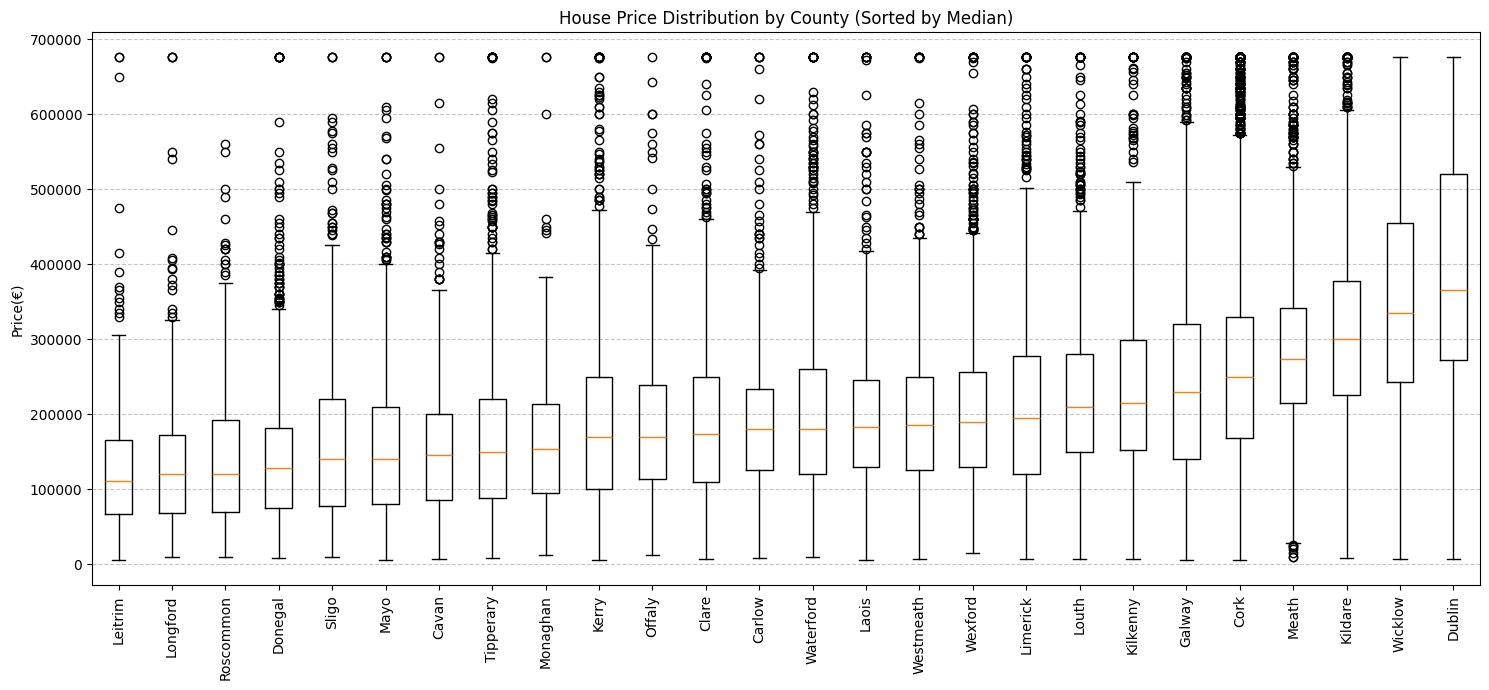

In [79]:

# sort by median
grouped = df.groupby('County')['Price(€)'].median().sort_values()

data_to_plot = [df[df['County'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by County (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

The boxplot shows a clear upward trend in median house prices across different counties,,with Dublin and its surrounding commuter belts (Wicklow, Kildare, Meath) commanding the highest premiums. This strong correlation between County and Price validates the use of the geographic location serves as a primary baseline for the model's price estimation.

## 2. Pair the price with Region

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\2002892232.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('Region')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\2002892232.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


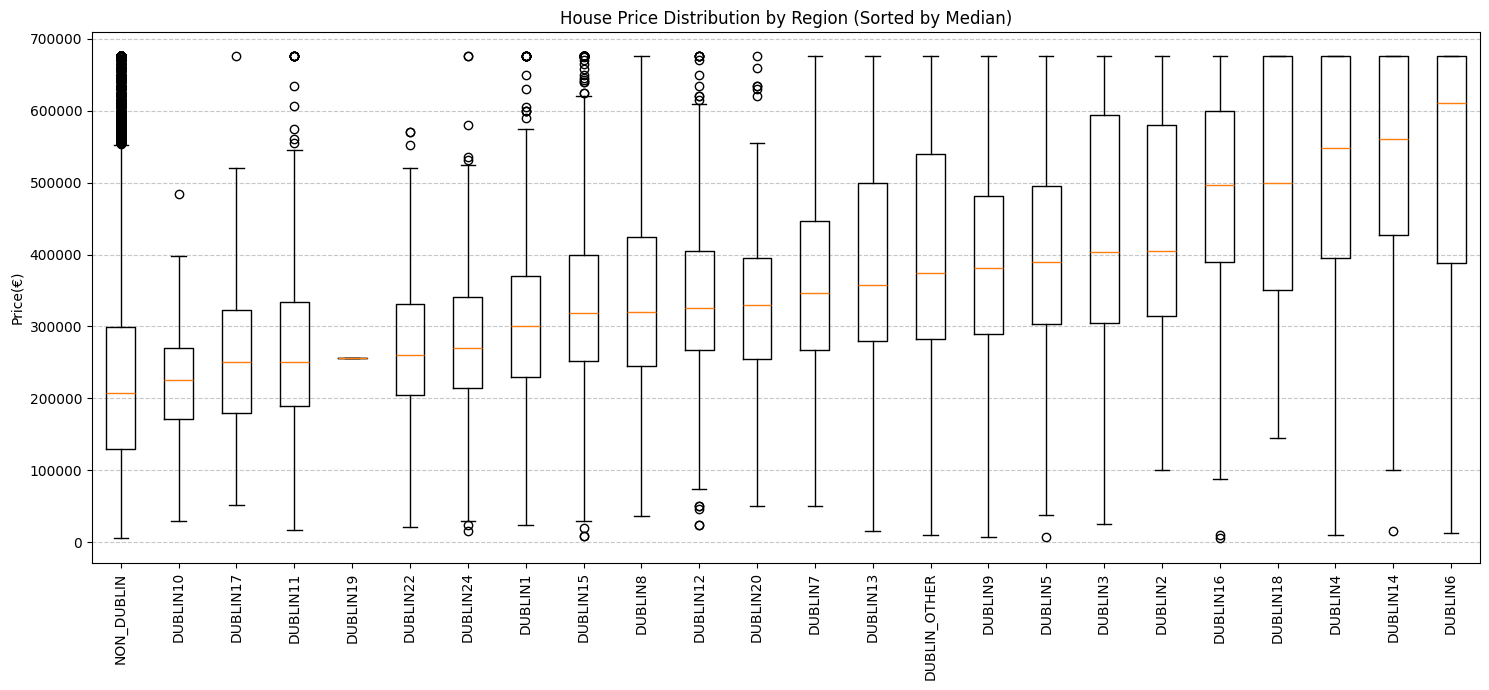

In [80]:

# sort by median
grouped = df.groupby('Region')['Price(€)'].median().sort_values()

data_to_plot = [df[df['Region'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by Region (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

In region, we focus on the districts inside Dublin. There is a significant price gap across different postal districts, with premium areas like Dublin 6, 14, and 4 showing median prices nearly double those of districts like Dublin 10 or 11. The distinct "staircase" effect of the medians validates that district is a much stronger predictor than a generic "Dublin" label. So we need to combine county and region together to encode the geographic location.

### Feature Engineering of County and Region
As county and region are both features of geography, we are going to integrate them as one feature. That is, for those in county Dublin, we substitute the value with region. The feature should be numeric for modeling, so for the each region, we use the average price of that region as the value of the feature. To avoid dataleakage, we would use the average price of previous year to encode the region of current year.




## 3. Pair the price with SaleYear


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\1065106022.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('SaleYear')['Price(€)'].median()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\1065106022.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


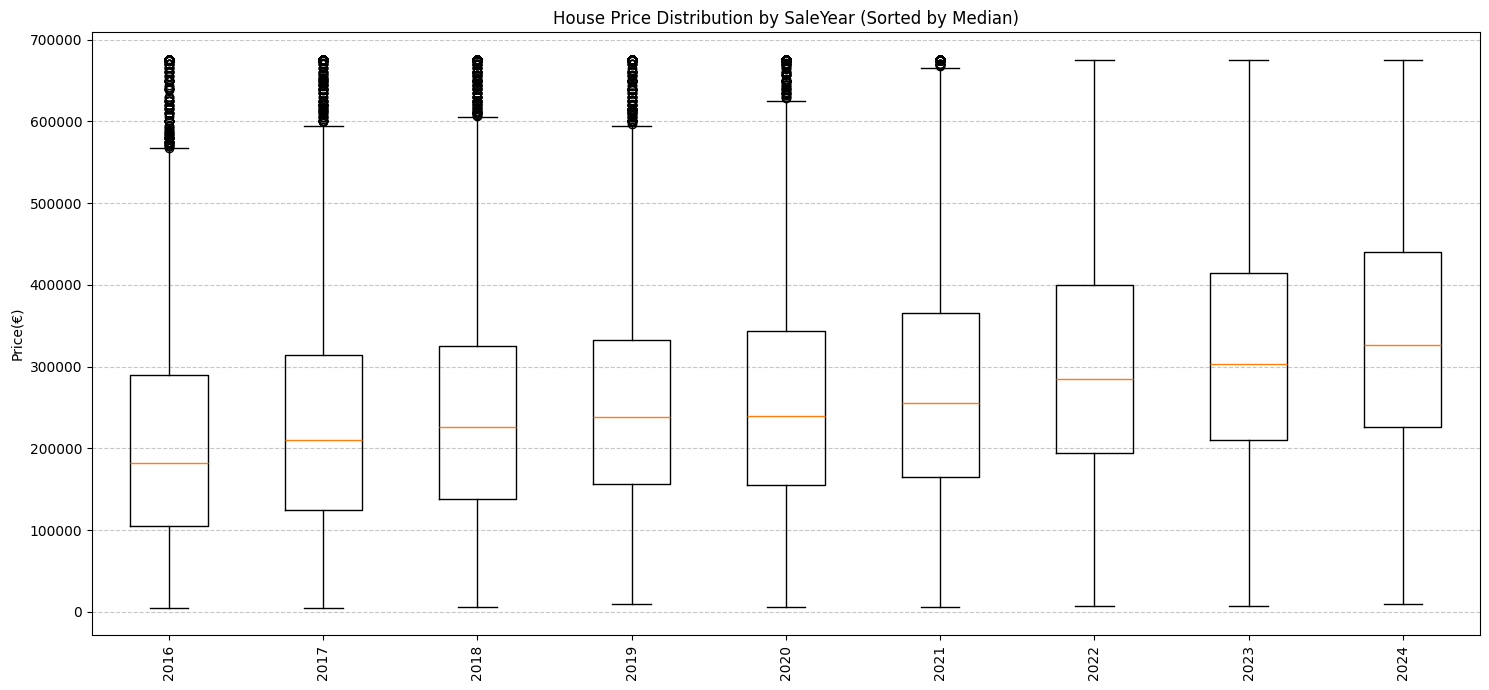

In [81]:
# sort by year
grouped = df.groupby('SaleYear')['Price(€)'].median()

data_to_plot = [df[df['SaleYear'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by SaleYear (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

The result shows a linear relationship between SaleYear and the median of price. There is a consistent year-on-year increase in both the median price and the overall price range from 2016 to 2024, reflecting the long-term growth trend in the national housing market.

## 4. Pair the price with SaleMonth
Result shows no direct relationship between month and price. The price distrubution is similiar in every month.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\1322693201.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('SaleMonth')['Price(€)'].median()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\1322693201.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


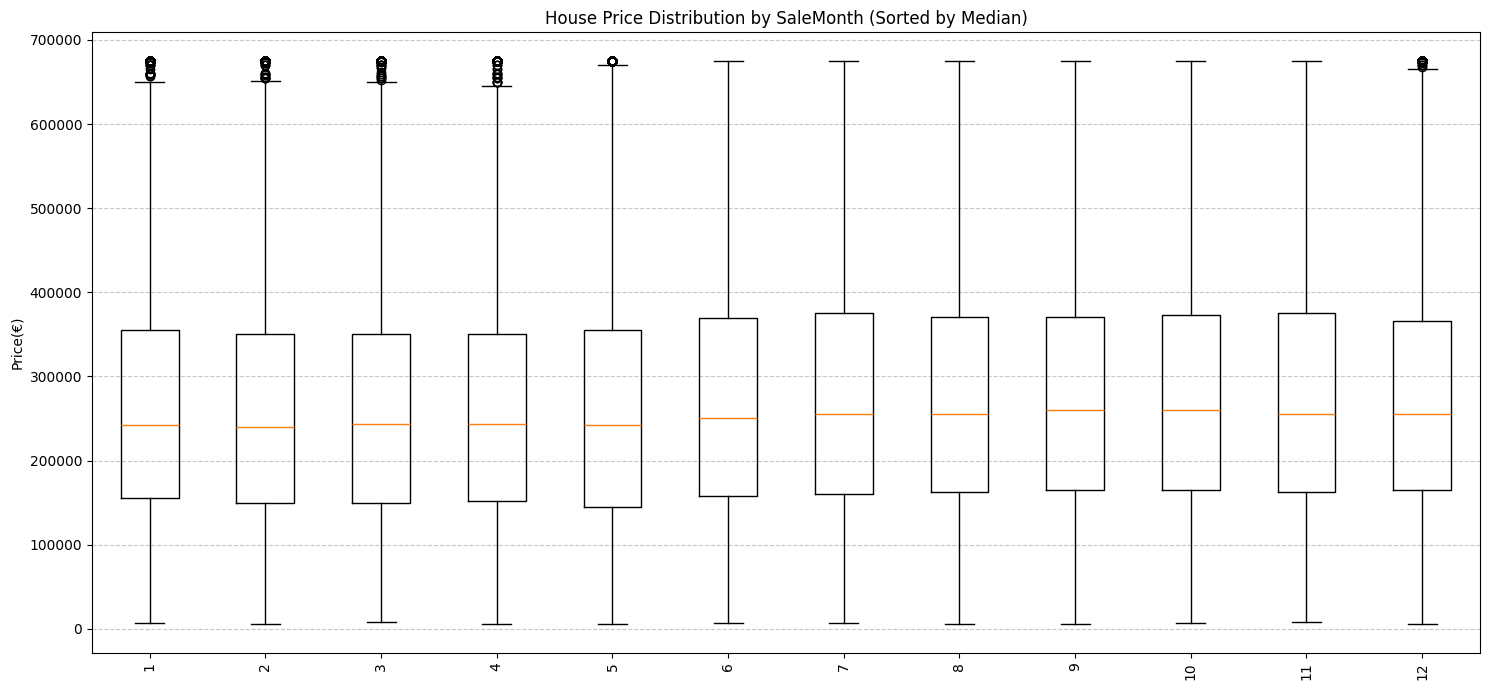

In [82]:

# sort by month
grouped = df.groupby('SaleMonth')['Price(€)'].median()

data_to_plot = [df[df['SaleMonth'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by SaleMonth (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

The median prices across all twelve months remain remarkably stable, suggesting that month-of-sale has a negligible impact on the base price compared to location or year.

## 5. Pair price with YearMonth
But as month is part of the time feature, to better find the relationship between time and price, we need to combine year and month together to pair with price. 

In [83]:
# combine year and month together.
df['YearMonth']=df['SaleYear'].astype('int64')*100+df['SaleMonth'].astype('int64')
df['YearMonth']=df['YearMonth'].astype('category')
df['SaleYear']=df['SaleYear'].astype('category')
df['SaleMonth']=df['SaleMonth'].astype('category')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\276334388.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('YearMonth')['Price(€)'].median()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\276334388.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


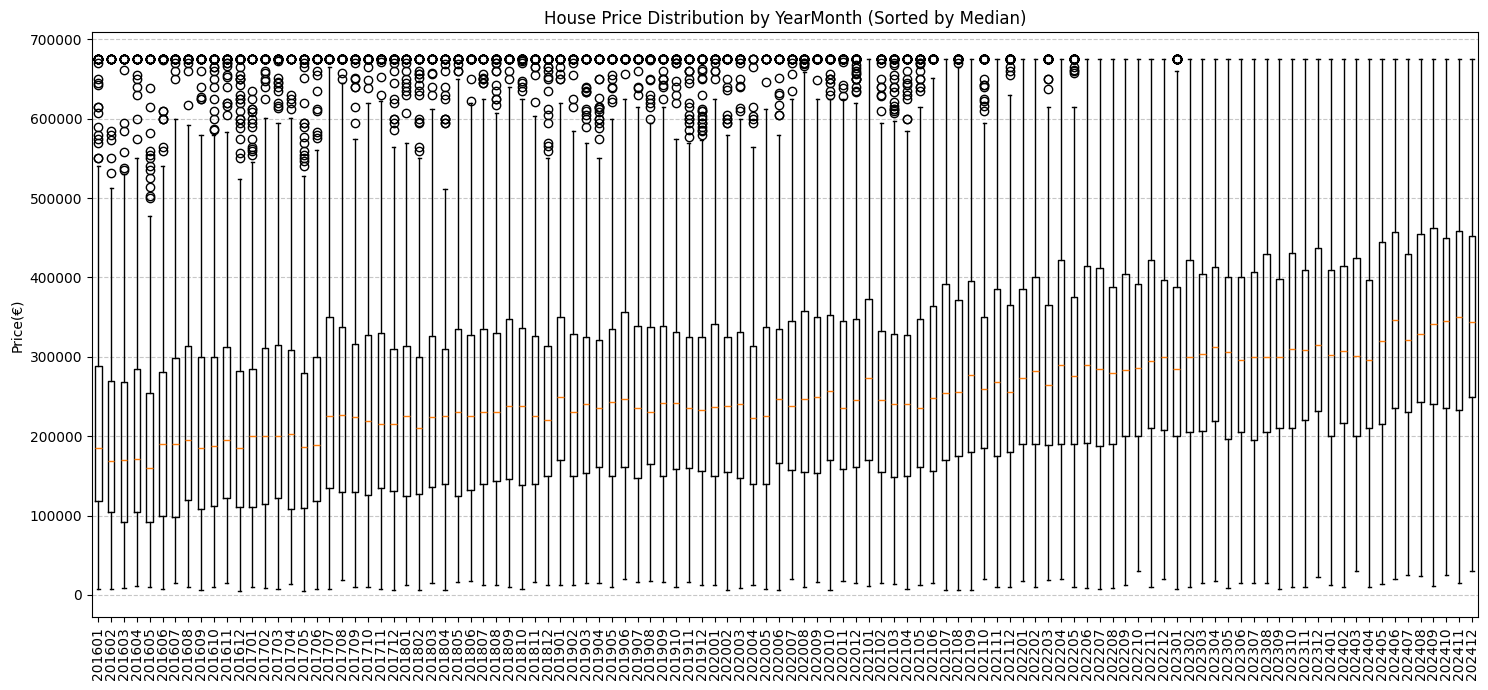

In [84]:
# pair the price with YearMonth

# sort by YearMonth
grouped = df.groupby('YearMonth')['Price(€)'].median()

data_to_plot = [df[df['YearMonth'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by YearMonth (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

By combining Year and Month into a single timeline, the plot reveals a clear, steady upward "staircase" in property values, showing that inflation in the Irish market is a continuous process rather than just a year-on-year jump.This visualization perfectly supports the use of a SaleMonthIndex. It allows the model to treat time as a continuous numerical sequence, capturing the incremental value growth that a simple "Month" or "Year" category would miss.

## 6. Pair the price with NotFullMarketPrice

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\55224881.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('NotFullMarketPrice')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\55224881.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


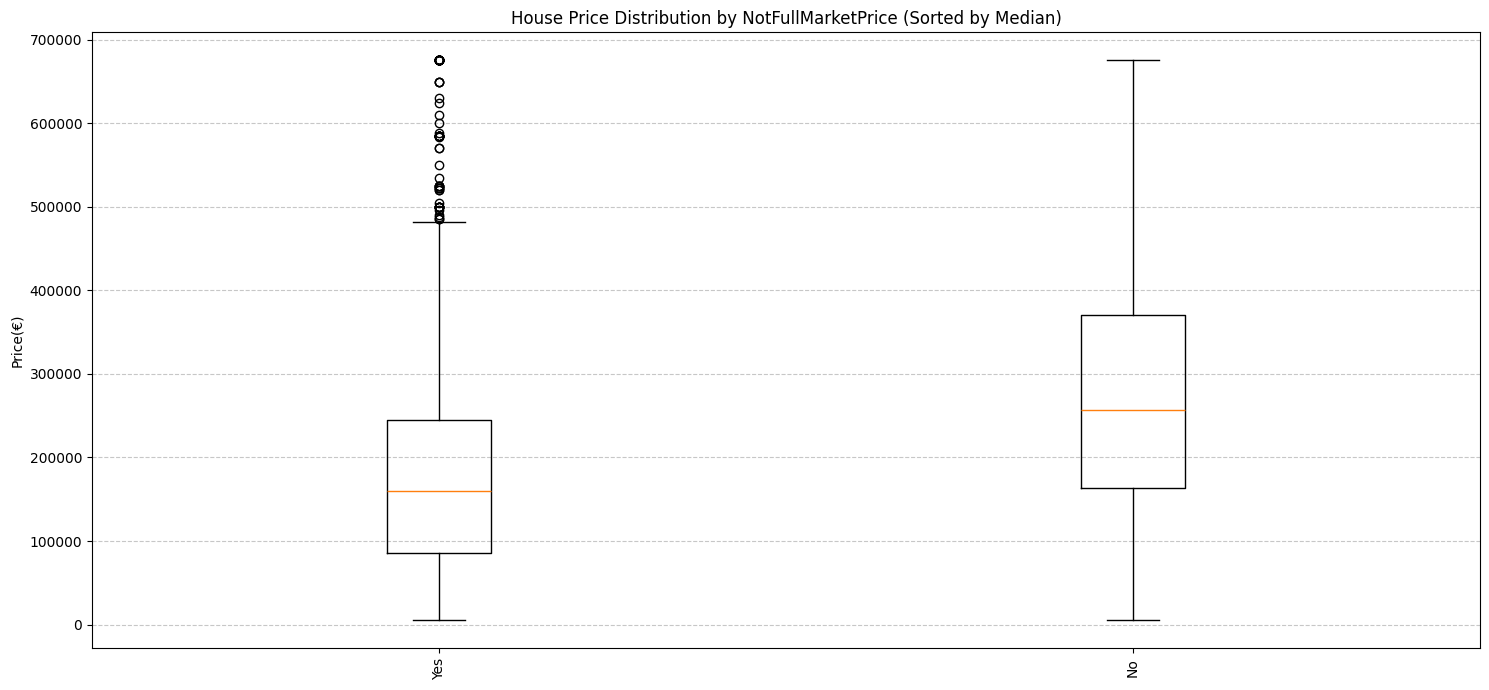

In [85]:
# sort by median
grouped = df.groupby('NotFullMarketPrice')['Price(€)'].median().sort_values()

data_to_plot = [df[df['NotFullMarketPrice'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by NotFullMarketPrice (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

There is a sharp difference in median prices between the two categories. Properties sold at "Not Full Market Price" (left) have a much lower median. 

## 7. Pair the price with VATExclusive

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\1832901416.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('VATExclusive')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\1832901416.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


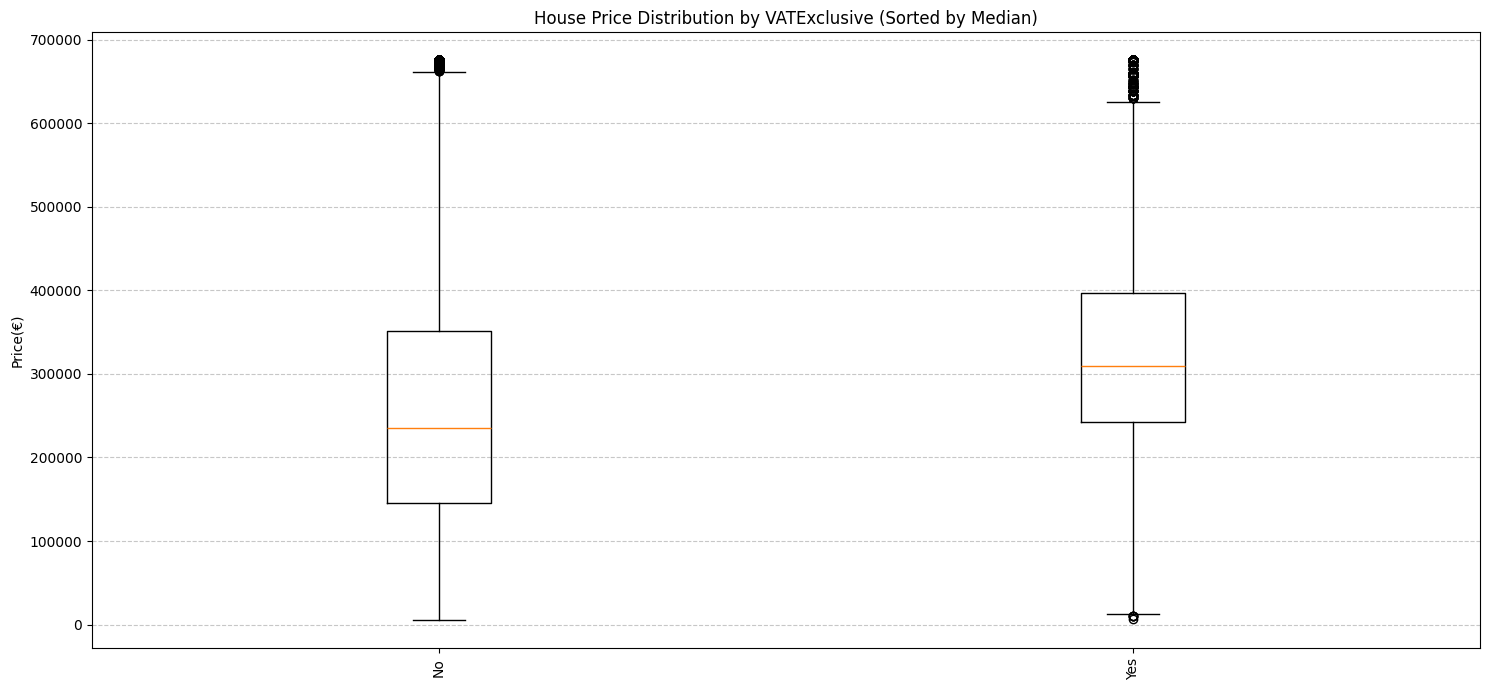

In [86]:
# sort by median
grouped = df.groupby('VATExclusive')['Price(€)'].median().sort_values()

data_to_plot = [df[df['VATExclusive'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by VATExclusive (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

Properties marked as "VATExclusive" (Yes)—which are typically brand-new developments—show a noticeably higher median price compared to non-VAT properties.

## 8. Pair the price with DescriptionofProperty


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\1038399458.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('DescriptionofProperty')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28872\1038399458.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


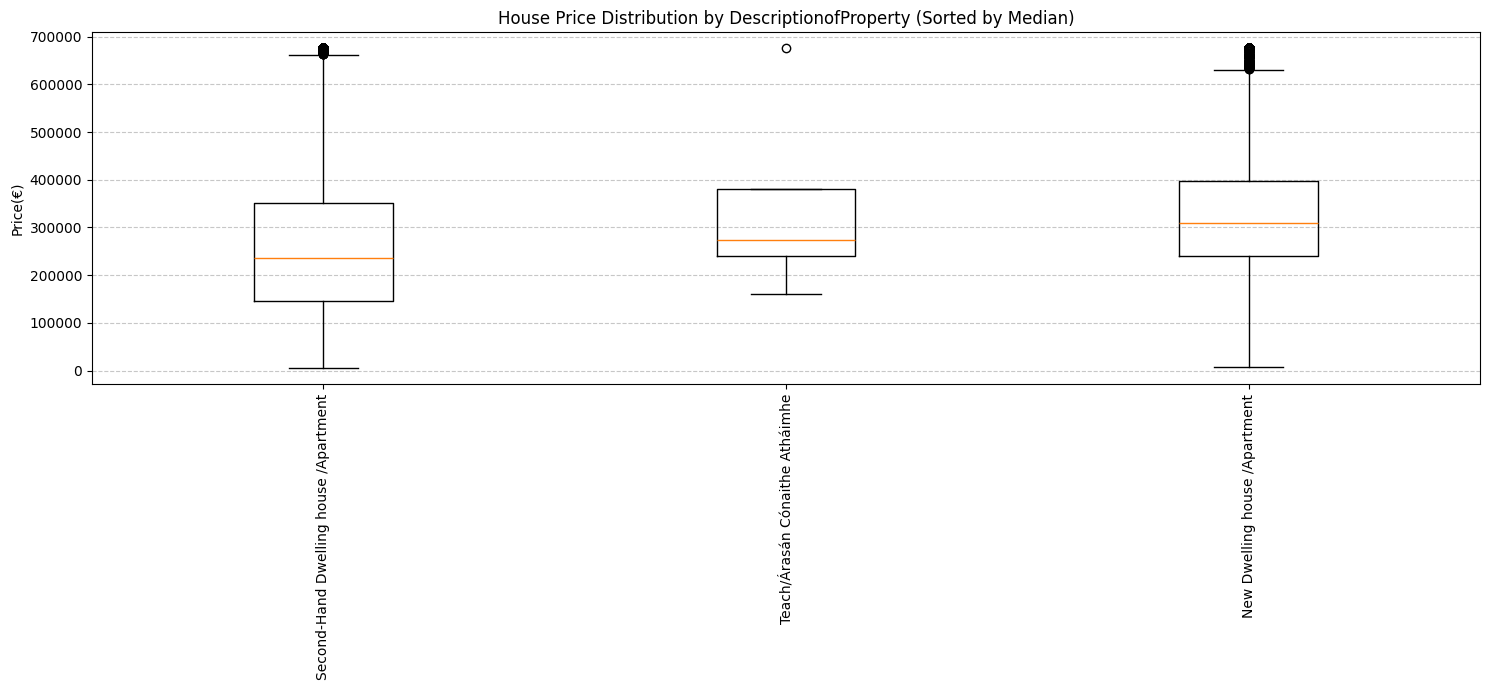

In [87]:
# sort by median
grouped = df.groupby('DescriptionofProperty')['Price(€)'].median().sort_values()

data_to_plot = [df[df['DescriptionofProperty'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by DescriptionofProperty (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

The result shows that there is apparent difference between the three categaries of the feature. <br> And we did some more investigation. There are 4 rows with value "Teach/Árasán Cónaithe Atháimhe", and this is actually "Second-Hand Dwelling house /Apartment" in Irish. So in feature engineering, we are also change DescriptionofProperty into binary numbers and assign "Second-Hand Dwelling house /Apartment" and "Teach/Árasán Cónaithe Atháimhe" with the same value.<br>According to the plot, prices in "New Dwelling house /Apartment" are generally hight than in "Second-Hand Dwelling house /Apartment"

In [88]:
df['DescriptionofProperty'].value_counts()

DescriptionofProperty
Second-Hand Dwelling house /Apartment    43123
New Dwelling house /Apartment             9532
Teach/Árasán Cónaithe Atháimhe               4
Name: count, dtype: int64

#### Feature Relationship Analysis
Based on our boxplots, we can see how different features affect house prices:<br>
1. Primary Linear Drivers (Geography & Time) <br>
(1) Geographic Factors (County & Region): The boxplots for both County and Dublin districts show a clear "staircase" trend in median prices. This proves that location is a very strong factor. There is a clear price difference between rural counties and expensive Dublin areas like Dublin 6 or Dublin 4.<br>
(2)Time Trends (YearMonth): The "Month" plot alone didn't show much, but the combined YearMonth graph shows a steady upward line. This confirms that house prices in Ireland have been rising since 2016, so using a continuous time index will help the model a lot. <br>
2. Key Categorical Factors <br>
(1) Market Authenticity (NotFullMarketPrice): There is a big drop in the median price for "Not Full Market" sales. This shows that these transactions are usually much cheaper than normal market sales, so this is an important feature for our model. <br>
(2) New-Build Premium (VATExclusive & Description): Both the VAT and Property Description plots show that New Dwellings are more expensive. We can see that new houses have higher "lower-whiskers" (minimum prices), which proves that being a "new build" always adds a basic extra cost to the property's value.<br>


# Feature Engineering
## 1. SaleYear and SaleMonth
Convert them into a month index SaleMonthIndex

In [89]:
# change data type of saleyear and salemonth
df["SaleYear"] = df["SaleYear"].astype(int)
df["SaleMonth"] = df["SaleMonth"].astype(int)
# create month index starting from 2016-01
df["SaleMonthIndex"] = (df["SaleYear"] - 2016) * 12 + df["SaleMonth"]
# check result
df[["SaleYear", "SaleMonth", "SaleMonthIndex"]].head(12000)

,SaleYear,SaleMonth,SaleMonthIndex
0,2016,7,7
1,2016,12,12
2,2016,8,8
3,2016,2,2
4,2016,10,10
...,...,...,...
11995,2018,12,36
11996,2018,3,27
11997,2018,9,33
11998,2018,7,31


## 2. NotFullMarketPrice
Change it into binary number, yes-1, no-0

In [90]:
print(df["NotFullMarketPrice"].unique())
df["NotFullMarketPrice"] = df["NotFullMarketPrice"].map({
    "Yes": 1,
    "No": 0
})
print(df["NotFullMarketPrice"].head())

['No', 'Yes']
Categories (2, object): ['No', 'Yes']
0    0
1    1
2    0
3    0
4    0
Name: NotFullMarketPrice, dtype: category
Categories (2, int64): [0, 1]


## 3. VATExclusive
Change it into binary number, yes-1, no-0

In [91]:
print(df["VATExclusive"].unique())
df["VATExclusive"] = df["VATExclusive"].map({
    "Yes": 1,
    "No": 0
})
print(df["VATExclusive"].head())

['No', 'Yes']
Categories (2, object): ['No', 'Yes']
0    0
1    0
2    0
3    1
4    0
Name: VATExclusive, dtype: category
Categories (2, int64): [0, 1]


## 4. DescriptionofProperty
Change it into two binary feature, new -1，second-hand -0.    

'Teach/Árasán Cónaithe Atháimhe' means second house/apartment in Irish, so we all merge 'Teach/Árasán Cónaithe Atháimhe' into second-hand house.

In [92]:
print(df["DescriptionofProperty"].unique())

['Second-Hand Dwelling house /Apartment', 'New Dwelling house /Apartment', 'Teach/Árasán Cónaithe Atháimhe']
Categories (3, object): ['New Dwelling house /Apartment', 'Second-Hand Dwelling house /Apartment', 'Teach/Árasán Cónaithe Atháimhe']


In [93]:
df["DescriptionofProperty"] = df["DescriptionofProperty"].map({
    "Second-Hand Dwelling house /Apartment": 0,
    "New Dwelling house /Apartment": 1,
    "Teach/Árasán Cónaithe Atháimhe":0
})
print(df["DescriptionofProperty"].head(1000))

0      0
1      0
2      0
3      1
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: DescriptionofProperty, Length: 1000, dtype: int64


## 5. County and Region encoding
Strategy:<br>
(1) To ensure statistical reliability and prevent Data Leakage, geographic features are encoded using a Time-Lagged Target Encoding approach. The encoding follows a hierarchical "back-off" logic to handle data sparsity:<br>
(a) Temporal Consistency: Observations in Year N are encoded using the mean property price from the preceding period (Year N-1). This simulates real-world logic and ensures no future information influences the model.<br>
(b) Minimum Sample Threshold: A minimum of 10 observations is required to calculate a valid regional mean. If this threshold is met, the single-year mean is applied.<br>
(c) Adaptive Back-off Mechanism:<br>
Window Expansion: If the sample size for N-1 is below 10, the calculation window expands to include the last two years (N-1 and N-2).<br>
Imputation: For Dublin sub-districts that fail the 2-year aggregate threshold, the encoding falls back to the DUBLIN_OTHER surrogate value. According to the samples, there are enough samples for other counties to calculate the average price.

In [94]:
# firstly, integrate county and region together as region.
df['Region'] = np.where(df['Region'] == 'NON_DUBLIN', df['County'], df['Region'])

df['Region'].value_counts()

Region
DUBLIN_OTHER    7734
Cork            5874
Kildare         3025
Galway          2412
Meath           2318
Limerick        1892
Wexford         1872
Wicklow         1853
Louth           1458
Waterford       1450
Kerry           1436
Tipperary       1360
Donegal         1352
Mayo            1258
Clare           1198
Westmeath       1027
DUBLIN15         947
Laois            876
Roscommon        854
Kilkenny         850
Sligo            800
Cavan            793
Offaly           691
Carlow           579
DUBLIN8          567
DUBLIN7          540
DUBLIN12         520
DUBLIN24         511
DUBLIN4          506
DUBLIN9          497
DUBLIN18         479
Leitrim          451
Longford         437
DUBLIN3          426
DUBLIN11         424
Monaghan         420
DUBLIN16         409
DUBLIN14         409
DUBLIN6          380
DUBLIN5          359
DUBLIN13         326
DUBLIN1          294
DUBLIN22         293
DUBLIN2          185
DUBLIN10         145
DUBLIN20          92
DUBLIN17          79
DUBLIN

In [95]:
# There is only one 'DUBLIN19', and it could be noise. So merge it into 'DUBLIN_OTHER'

df['Region']=df['Region'].replace('DUBLIN19','DUBLIN_OTHER')
df['Region'].value_counts()

Region
DUBLIN_OTHER    7735
Cork            5874
Kildare         3025
Galway          2412
Meath           2318
Limerick        1892
Wexford         1872
Wicklow         1853
Louth           1458
Waterford       1450
Kerry           1436
Tipperary       1360
Donegal         1352
Mayo            1258
Clare           1198
Westmeath       1027
DUBLIN15         947
Laois            876
Roscommon        854
Kilkenny         850
Sligo            800
Cavan            793
Offaly           691
Carlow           579
DUBLIN8          567
DUBLIN7          540
DUBLIN12         520
DUBLIN24         511
DUBLIN4          506
DUBLIN9          497
DUBLIN18         479
Leitrim          451
Longford         437
DUBLIN3          426
DUBLIN11         424
Monaghan         420
DUBLIN14         409
DUBLIN16         409
DUBLIN6          380
DUBLIN5          359
DUBLIN13         326
DUBLIN1          294
DUBLIN22         293
DUBLIN2          185
DUBLIN10         145
DUBLIN20          92
DUBLIN17          79
Name: 

In [96]:
# Check the samples grouped by region and year both in a single year and in two years that are less than 10.

# pair the region with year and count the number of samples in a single year
annual_counts = df.groupby(['SaleYear', 'Region']).size().reset_index(name='single_year_count')

# count the number of samples of the same region in two yeas.
annual_counts['two_year_total'] = annual_counts.groupby('Region')['single_year_count'].rolling(window=2, min_periods=1).sum().reset_index(level=0, drop=True)

# pick those less than 10 and null values out.
sparse_1y = annual_counts[(annual_counts['single_year_count'] < 10) | (annual_counts['single_year_count'].isna())]
sparse_2y = annual_counts[(annual_counts['two_year_total'] < 10) | (annual_counts['two_year_total'].isna())]

# print region-year pair less than 10 in a single year.
print(f"There are {len(sparse_1y)} year-region pairs whose samples are less than 10.")
print(sparse_1y.sort_values(by='single_year_count').to_string(index=False))

# print region-year pair less than 10 in two years.
if sparse_2y.empty:
    print("All samples in two_year_rolling are more than 10.")
else:
    print(f"There are {len(sparse_2y)} groups whose samples are less than 10 in two_year_rolling")
    print(sparse_2y[['SaleYear', 'Region', 'two_year_total']].sort_values(by='two_year_total').to_string(index=False))

There are 10 year-region pairs whose samples are less than 10.
 SaleYear   Region  single_year_count  two_year_total
     2018 DUBLIN20                  4            15.0
     2020 DUBLIN17                  4             9.0
     2024 DUBLIN17                  4            14.0
     2019 DUBLIN17                  5            14.0
     2023 DUBLIN20                  7            17.0
     2019 DUBLIN20                  8            12.0
     2016 DUBLIN17                  8             8.0
     2018 DUBLIN17                  9            23.0
     2021 DUBLIN10                  9            24.0
     2024 DUBLIN20                  9            16.0
There are 2 groups whose samples are less than 10 in two_year_rolling
 SaleYear   Region  two_year_total
     2016 DUBLIN17             8.0
     2020 DUBLIN17             9.0


Here, there are two groups whose samples do not meet the standard of >=10 in two years. They are both DUBLIN17. We are going to use the value of  DUBLIN_OTHER as subsititution, which includes all that does not specificate the distrcits.<br><br>

Now start to encoding the region.<br>
First, calculate the average price and count the number of samples grouped by region and year (both in single year and in two years).

In [97]:

# 1. calculate the mean and count sample number in a single year
stats_1y = df.groupby(['SaleYear', 'Region'])['Price(€)'].agg(['mean', 'count']).reset_index()

# 2. calculate the mean and count sample number in two years. As 2016 has no prevous year, its two-year values are filled with the value in 2016 only
stats_2y = stats_1y.sort_values(['Region', 'SaleYear']).copy()
stats_2y['rolling_sum'] = stats_2y.groupby('Region')['mean'].transform(lambda x: x * stats_2y['count'])
stats_2y['cum_count_2y'] = stats_2y.groupby('Region')['count'].transform(lambda x: x.rolling(window=2, min_periods=1).sum())
stats_2y['cum_mean_2y'] = stats_2y.groupby('Region')['rolling_sum'].transform(lambda x: x.rolling(window=2, min_periods=1).sum()) / stats_2y['cum_count_2y']

# 3. pick out the mean of DUBLIN_OTHER for later substitution 
stats_dublin_other = df[df['Region'] == 'DUBLIN_OTHER'].groupby('SaleYear')['Price(€)'].mean().reset_index(name='dublin_other_mean')

# 4. calculate the mean of 2016 only to fill the first year when merging.
stats_2016 = df[df['SaleYear'] == 2016].groupby('Region')['Price(€)'].mean().reset_index(name='mean_2016')

Second, move the results forward by one year (mean of year N now becomes mean of year N+1)

In [98]:

lookup_1y = stats_1y[['SaleYear', 'Region', 'mean', 'count']].copy()
lookup_1y['SaleYear'] += 1

lookup_2y = stats_2y[['SaleYear', 'Region', 'cum_mean_2y', 'cum_count_2y']].copy()
lookup_2y['SaleYear'] += 1

lookup_dublin = stats_dublin_other.copy()
lookup_dublin['SaleYear'] += 1


Third, merge the result into df and fill the encoding.

In [99]:
# 1. merge all the results into the main df
df = df.merge(lookup_1y, on=['SaleYear', 'Region'], how='left', suffixes=('', '_1y'))
df = df.merge(lookup_2y, on=['SaleYear', 'Region'], how='left')
df = df.merge(lookup_dublin, on='SaleYear', how='left')
df = df.merge(stats_2016, on='Region', how='left')

# 2. set the column of new feature
df['Region_Encoded'] = np.nan
threshold = 10  

# fill the new feature by Hierarchy

# Hierarchy 1: mean of prevous year that has more than 10 samples
mask1 = df['count'] >= threshold
df.loc[mask1, 'Region_Encoded'] = df['mean']

# Hierarchy 2: mean of prevous two years that has more than 10 samples
mask2 = df['Region_Encoded'].isna() & (df['cum_count_2y'] >= threshold)
df.loc[mask2, 'Region_Encoded'] = df['cum_mean_2y']

# Hierarchy 3: for Regions in Dublin which does not meet Hierarchy 2, fill with the mean of DUBLIN_OTHER
dublin_regions = [r for r in df['Region'].unique() if 'Dublin' in r or r.isdigit()]
is_dublin = df['Region'].isin(dublin_regions)
mask3 = df['Region_Encoded'].isna() & is_dublin
df.loc[mask3, 'Region_Encoded'] = df['dublin_other_mean']

# for the first year 2016, fill it with its own mean
mask_2016 = df['Region_Encoded'].isna() & (df['SaleYear'] == 2016)
df.loc[mask_2016, 'Region_Encoded'] = df['mean_2016']

# use the total mean to cover the bottom
df['Region_Encoded'] = df['Region_Encoded'].fillna(df['Price(€)'].mean())

# 3. drop the unnecissary columns
cols_to_drop = ['mean', 'count', 'cum_mean_2y', 'cum_count_2y', 'dublin_other_mean','mean_2016']
df.drop(columns=cols_to_drop, inplace=True)

Forth, draw histogram and scatter plot to check the encoding.

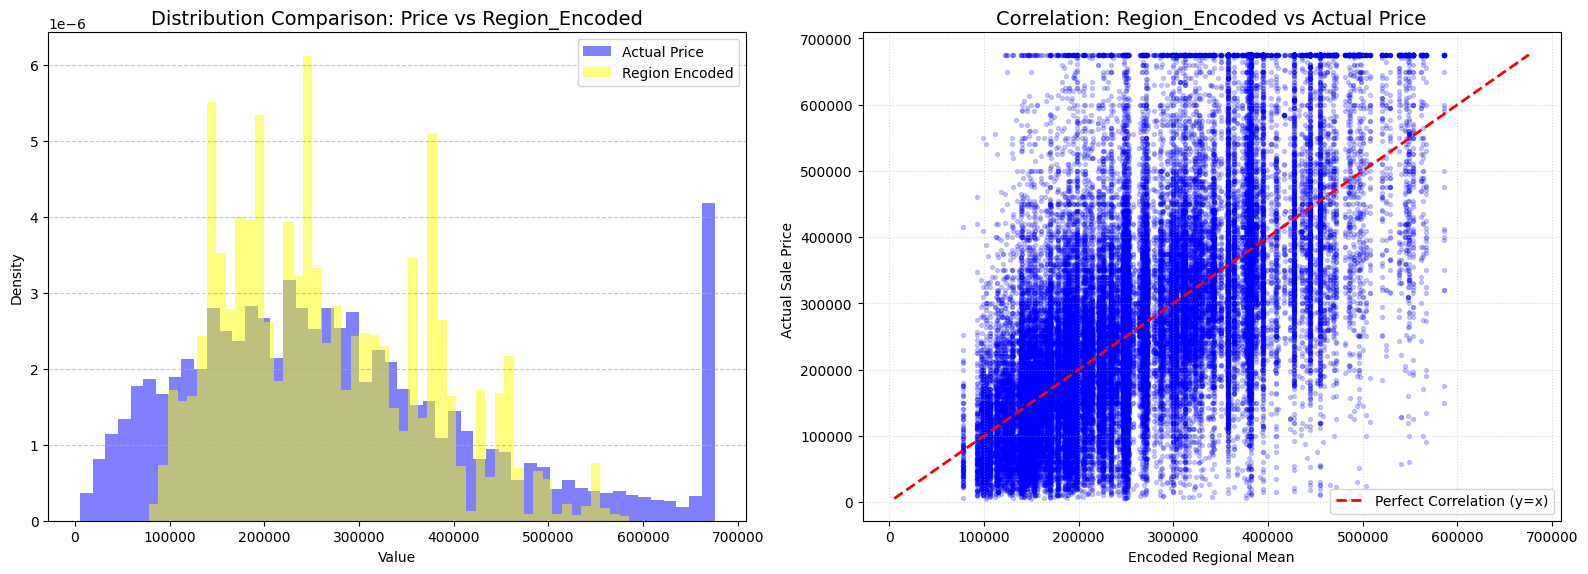

In [100]:

plt.figure(figsize=(16, 6))

# Histogram of Price and Region_Encoded
plt.subplot(1, 2, 1)
plt.hist(df['Price(€)'], bins=50, alpha=0.5, color='blue', label='Actual Price', density=True)
plt.hist(df['Region_Encoded'], bins=50, alpha=0.5, color='yellow', label='Region Encoded', density=True)

plt.title('Distribution Comparison: Price vs Region_Encoded', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Scatter Plot of Price and Region_Encoded
plt.subplot(1, 2, 2)
plt.scatter(df['Region_Encoded'], df['Price(€)'], alpha=0.2, s=8, color='blue')

# add a perfect line where y=x
limit_max = max(df['Price(€)'].max(), df['Region_Encoded'].max())
limit_min=min(df['Price(€)'].min(), df['Region_Encoded'].min())
plt.plot([limit_min, limit_max], [limit_min, limit_max], color='red', linestyle='--', linewidth=2, label='Perfect Correlation (y=x)')

plt.title('Correlation: Region_Encoded vs Actual Price', fontsize=14)
plt.xlabel('Encoded Regional Mean')
plt.ylabel('Actual Sale Price ')
plt.legend()
plt.grid(linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Left Plot (Distribution): The Region Encoding (yellow) basically acts as a "shortcut" to show the average price for each area. While it’s not as spread out as the Actual Prices (blue), it could give the model a solid numerical starting point.<br>
Right Plot (Correlation): Most blue dots clustering along the Red Diagonal. It proves that Location really is a big factor here, and our encoded values are doing a good job as a linear predictor.<br>
The "Ceiling" (Clamping): That flat line of dots at the top (around €675k) is our Clamping in action. It visually shows how we’ve capped the luxury outliers so they don't "bully" the model and mess up the results for regular houses.<br>
The Real Bottleneck: The big vertical gaps at each point show that Location isn't everything. The price is also affected by other factors which may not be included in the dateset.

# 6. Validate the engineered data

In [101]:
print(df.dtypes)

County                   category
Price(€)                  float64
NotFullMarketPrice       category
VATExclusive             category
DescriptionofProperty       int64
SaleYear                    int64
SaleMonth                   int64
Region                     object
YearMonth                category
SaleMonthIndex              int64
Region_Encoded            float64
dtype: object


Features for modeling are saved as numeric.<br>
Features not for modeling are saved as category.<br>
'SaleYear' should be category and dropped but we need it to group the data into training set and validation set, so we keep it as int.


In [102]:

df['Region']=df['Region'].astype('category')
df['NotFullMarketPrice']=df['NotFullMarketPrice'].astype('int64')
df['VATExclusive']=df['VATExclusive'].astype('int64')
df['SaleMonth']=df['SaleMonth'].astype('category')

print(df.dtypes)

County                   category
Price(€)                  float64
NotFullMarketPrice          int64
VATExclusive                int64
DescriptionofProperty       int64
SaleYear                    int64
SaleMonth                category
Region                   category
YearMonth                category
SaleMonthIndex              int64
Region_Encoded            float64
dtype: object


In [103]:
df.isnull().sum()

County                   0
Price(€)                 0
NotFullMarketPrice       0
VATExclusive             0
DescriptionofProperty    0
SaleYear                 0
SaleMonth                0
Region                   0
YearMonth                0
SaleMonthIndex           0
Region_Encoded           0
dtype: int64

In [104]:
df.nunique()

County                     26
Price(€)                 5762
NotFullMarketPrice          2
VATExclusive                2
DescriptionofProperty       2
SaleYear                    9
SaleMonth                  12
Region                     47
YearMonth                 108
SaleMonthIndex            108
Region_Encoded            376
dtype: int64

In [105]:
df.head(10)

,County,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonth,Region,YearMonth,SaleMonthIndex,Region_Encoded
0,Wexford,62500.0,0,0,0,2016,7,Wexford,201607,7,140133.584455
1,Cork,150000.0,1,0,0,2016,12,Cork,201612,12,198460.380569
2,Wexford,94000.0,0,0,0,2016,8,Wexford,201608,8,140133.584455
3,Leitrim,149500.0,0,1,1,2016,2,Leitrim,201602,2,78111.708000
4,Mayo,170000.0,0,0,0,2016,10,Mayo,201610,10,101768.538462
5,Galway,50000.0,0,0,0,2016,12,Galway,201612,12,169894.251731
6,Dublin,15000.0,0,0,0,2016,10,DUBLIN14,201610,10,486409.449362
7,Waterford,160000.0,0,0,0,2016,8,Waterford,201608,8,139912.414348
8,Kilkenny,320000.0,0,1,1,2016,12,Kilkenny,201612,12,178090.236923
9,Dublin,225000.0,0,0,0,2016,5,DUBLIN_OTHER,201605,5,357260.467719


In [106]:
# back up the engineered dataset
df.to_csv('ppr-group-25204989-train-Engineered.csv', index=False, encoding='utf-8')

Drop all the category columns and save the data for model.<br>

In [107]:
col_to_drop=df.select_dtypes('category')
df.drop(columns=col_to_drop, inplace=True)
print(df.dtypes)


Price(€)                 float64
NotFullMarketPrice         int64
VATExclusive               int64
DescriptionofProperty      int64
SaleYear                   int64
SaleMonthIndex             int64
Region_Encoded           float64
dtype: object


In [108]:
print("="*70)
print("SAVING DATASET FOR MODELING")
print("="*70)

# Define output filename with version indicator
output_filename = 'ppr-group-25204989-train-Formodeling.csv'

# Write the cleaned dataframe to a csv file with UTF-8 encoding
df.to_csv(output_filename, index=False, encoding='utf-8')

print(f"\n✓ Dataset for modeling saved successfully")
print(f"\nFile Information:")
print(f"  Filename: {output_filename}")
print(f"  Location: Current working directory")
print(f"  Format: CSV (UTF-8 encoding)")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")
print(f"\nDataset is now ready for:")
print(f"  - Modeling (building predictive models)")
print("="*70)



SAVING DATASET FOR MODELING

✓ Dataset for modeling saved successfully

File Information:
  Filename: ppr-group-25204989-train-Formodeling.csv
  Location: Current working directory
  Format: CSV (UTF-8 encoding)
  Rows: 52659
  Columns: 7

Dataset is now ready for:
  - Modeling (building predictive models)


## Summary for new features: 
### 1. SaleMonthIndex
Convert SaleYear and SaleMonth into a month index: SaleMonthIndex.
### 2. NotFullMarketPrice
Change it into binary number, yes-1, no-0.
### 3. VATExclusive
Change it into binary number, yes-1, no-0.
### 4. DescriptionofProperty
Change it into two binary feature, new -1，second-hand -0.    
### 5. Region_Encoded
Combine County and Region together, use the average price of previous year to encode the region of current year.

